# Segmented EDA and Source Audit

This notebook does two things:
1. Checks whether wait-time relationships become clearer when the prepared dataset is split by operational groups.
2. Audits the raw NHAMCS source to confirm whether important fields like REGION and SETTYPE exist upstream even if they are missing from the derived analysis file.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

project_root = Path("/Users/salmaibrahim/EDWaitTime")
eda_path = project_root / "data" / "eda_df.csv"
raw_path = project_root / "data" / "ed2022_sas.sas7bdat"

eda_df = pd.read_csv(eda_path)
print(f"Prepared dataset shape: {eda_df.shape}")
display(eda_df.head())

Prepared dataset shape: (92145, 23)


,WAITTIME,ARRTIME,VMONTH,VDAYR,AGE,SEX,RACEUN,ETHUN,IMMEDR,PAINSCALE,LOV,ADMIT,FASTTRAK,OBSCLIN,BOARD,BPSYS,BPDIAS,TEMPF,PULSE,RESPR,POPCT,ARRTIME_CLEAN,ARRIVAL_HOUR
0,18.0,b'1236',11.0,2.0,26.0,2.0,2.0,2.0,4.0,10.0,210.0,-7.0,1.0,1.0,1.0,108.0,66.0,981.0,90.0,17.0,97.0,12:36:00,12.0
1,103.0,b'2114',11.0,2.0,53.0,2.0,1.0,2.0,4.0,3.0,247.0,-7.0,1.0,1.0,1.0,148.0,78.0,981.0,77.0,16.0,96.0,21:14:00,21.0
2,73.0,b'1619',11.0,3.0,45.0,2.0,1.0,-9.0,3.0,8.0,174.0,-7.0,1.0,1.0,1.0,153.0,93.0,981.0,80.0,17.0,99.0,16:19:00,16.0
3,27.0,b'0950',11.0,4.0,40.0,1.0,1.0,2.0,4.0,7.0,94.0,-7.0,1.0,1.0,1.0,144.0,92.0,981.0,78.0,18.0,100.0,09:50:00,9.0
4,1.0,b'1738',11.0,4.0,35.0,2.0,1.0,2.0,4.0,5.0,150.0,-7.0,1.0,1.0,1.0,142.0,88.0,986.0,105.0,16.0,99.0,17:38:00,17.0


In [10]:
# Audit the prepared dataset completely so we know what was and was not included.
all_cols = pd.DataFrame({
    'column': eda_df.columns,
    'dtype': eda_df.dtypes.astype(str).values,
    'missing_pct': (eda_df.isna().mean().values * 100).round(2),
})
display(all_cols)

print('Columns in prepared data:')
print(', '.join(eda_df.columns))

absent_in_prepared = ['REGION', 'SETTYPE']
print('\nMissing from prepared data if expected upstream:')
print([c for c in absent_in_prepared if c not in eda_df.columns])

,column,dtype,missing_pct
0,WAITTIME,float64,0.0
1,ARRTIME,object,0.0
2,VMONTH,float64,0.0
3,VDAYR,float64,0.0
4,AGE,float64,0.0
5,SEX,float64,0.0
6,RACEUN,float64,0.0
7,ETHUN,float64,0.0
8,IMMEDR,float64,0.0
9,PAINSCALE,float64,0.0


Columns in prepared data:
WAITTIME, ARRTIME, VMONTH, VDAYR, AGE, SEX, RACEUN, ETHUN, IMMEDR, PAINSCALE, LOV, ADMIT, FASTTRAK, OBSCLIN, BOARD, BPSYS, BPDIAS, TEMPF, PULSE, RESPR, POPCT, ARRTIME_CLEAN, ARRIVAL_HOUR

Missing from prepared data if expected upstream:
['REGION', 'SETTYPE']


In [3]:
# Start with all numeric columns, then inspect the strongest relationships and grouped differences.
numeric_cols = eda_df.select_dtypes(include='number').columns.tolist()
corr_series = eda_df[numeric_cols].corr(numeric_only=True)['WAITTIME'].drop('WAITTIME').sort_values(key=lambda s: s.abs(), ascending=False)
display(corr_series.to_frame('pearson_corr'))

segment_cols = [c for c in ['FASTTRAK', 'OBSCLIN', 'BOARD', 'ADMIT', 'IMMEDR', 'VDAYR', 'VMONTH', 'ARRIVAL_HOUR'] if c in eda_df.columns]
segment_summary = []
for col in segment_cols:
    grouped = eda_df.groupby(col, dropna=False)['WAITTIME'].agg(['count', 'mean', 'median']).reset_index()
    grouped['variable'] = col
    grouped['mean_spread'] = grouped['mean'].max() - grouped['mean'].min()
    segment_summary.append(grouped)

if segment_summary:
    segment_summary_df = pd.concat(segment_summary, ignore_index=True)
    display(segment_summary_df)

top_segments = pd.DataFrame({
    'variable': [],
    'mean_spread': []
})
if segment_summary:
    top_segments = (
        segment_summary_df.groupby('variable', as_index=False)['mean_spread']
        .max()
        .sort_values('mean_spread', ascending=False)
    )
display(top_segments)

,pearson_corr
LOV,0.132783
FASTTRAK,-0.042357
BOARD,-0.030976
ARRIVAL_HOUR,0.020063
TEMPF,0.014855
OBSCLIN,-0.014819
ETHUN,0.012604
VDAYR,-0.012486
AGE,-0.010968
SEX,-0.010709


,FASTTRAK,count,mean,median,variable,mean_spread,OBSCLIN,BOARD,ADMIT,IMMEDR,VDAYR,VMONTH,ARRIVAL_HOUR
0,-9.0,166,54.831325,30.5,FASTTRAK,21.602450,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-8.0,6173,45.738539,21.0,FASTTRAK,21.602450,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,52469,38.036746,16.0,FASTTRAK,21.602450,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,33337,33.228875,15.0,FASTTRAK,21.602450,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,135,64.200000,37.0,OBSCLIN,29.295292,-9.0,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,5445,38.631772,18.0,OBSCLIN,29.295292,-8.0,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,39069,38.856792,17.0,OBSCLIN,29.295292,1.0,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,47496,34.904708,15.0,OBSCLIN,29.295292,2.0,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,135,64.200000,37.0,BOARD,33.948710,NaN,-9.0,NaN,NaN,NaN,NaN,NaN
9,NaN,5557,42.644412,20.0,BOARD,33.948710,NaN,-8.0,NaN,NaN,NaN,NaN,NaN


,variable,mean_spread
2,BOARD,33.948710
5,OBSCLIN,29.295292
1,ARRIVAL_HOUR,22.370605
3,FASTTRAK,21.602450
0,ADMIT,21.489979
4,IMMEDR,16.426173
7,VMONTH,10.134859
6,VDAYR,8.305159


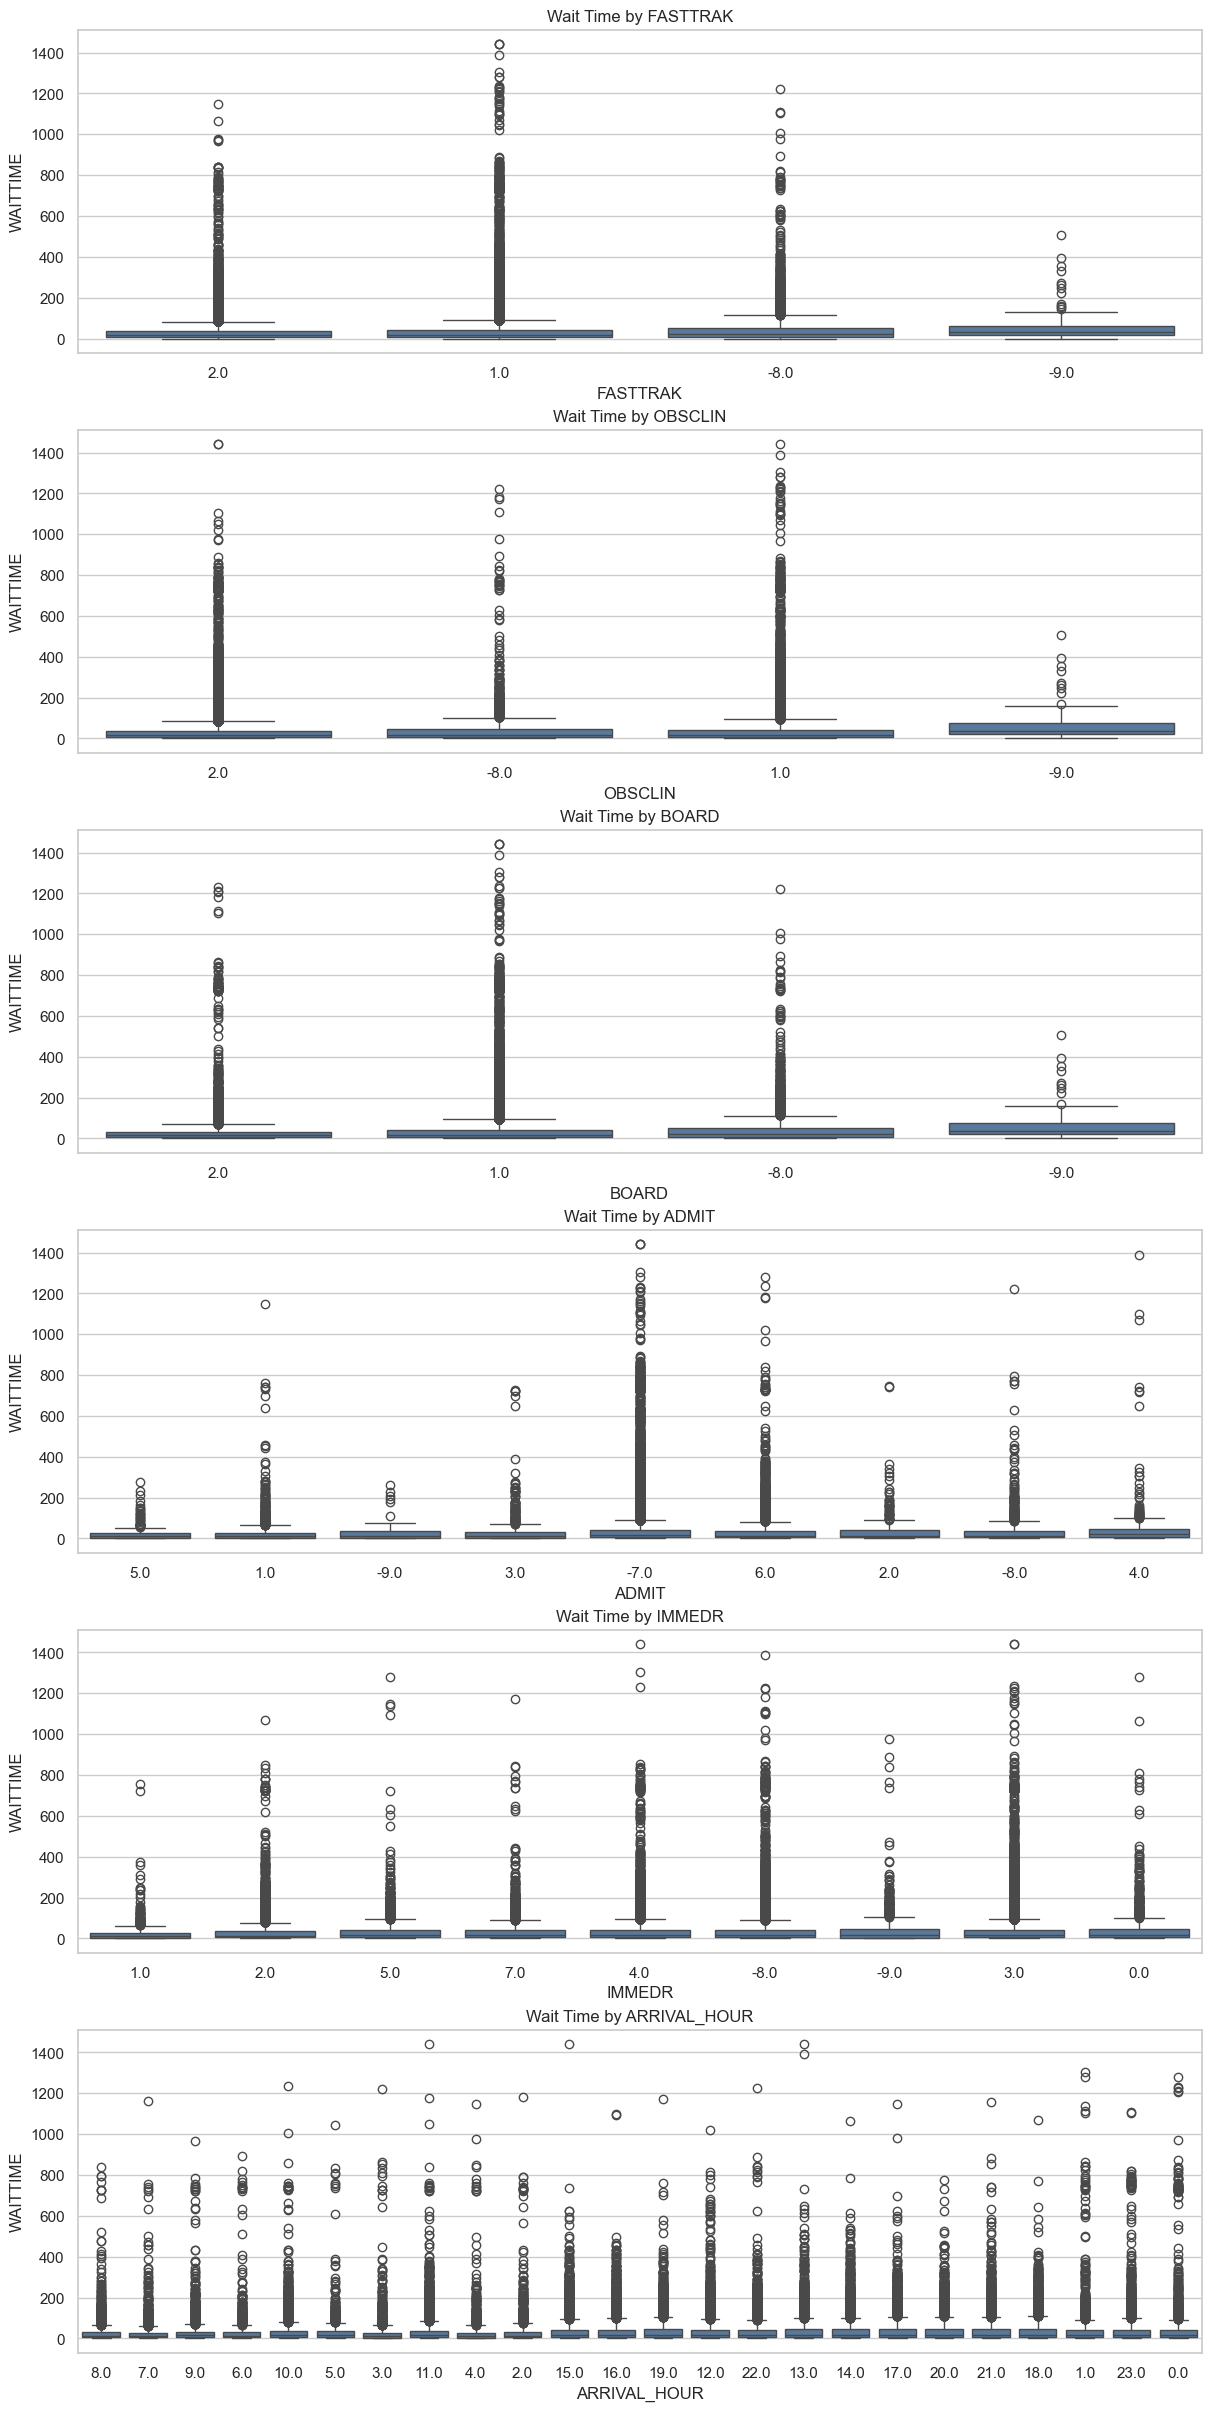

In [4]:
# Plot the segments that create the clearest separation in average wait time.
plot_vars = [c for c in ['FASTTRAK', 'OBSCLIN', 'BOARD', 'ADMIT', 'IMMEDR', 'ARRIVAL_HOUR'] if c in eda_df.columns]
fig, axes = plt.subplots(len(plot_vars), 1, figsize=(12, 4 * len(plot_vars)), constrained_layout=True)
if len(plot_vars) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_vars):
    order = eda_df.groupby(col)['WAITTIME'].mean().sort_values().index
    sns.boxplot(data=eda_df, x=col, y='WAITTIME', order=order, ax=ax, color='#4c78a8')
    ax.set_title(f'Wait Time by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('WAITTIME')

plt.show()

In [5]:
# Audit the raw SAS source to confirm whether REGION and SETTYPE exist upstream.
raw_reader = pd.read_sas(raw_path, format='sas7bdat', encoding='latin1', iterator=True)
raw_chunk = next(raw_reader)
print(f'Raw source columns: {len(raw_chunk.columns)}')
print('REGION in raw source:', 'REGION' in raw_chunk.columns)
print('SETTYPE in raw source:', 'SETTYPE' in raw_chunk.columns)

source_check = raw_chunk[[c for c in ['REGION', 'SETTYPE', 'WAITTIME', 'IMMEDR', 'FASTTRAK'] if c in raw_chunk.columns]].head(20)
display(source_check)

Raw source columns: 913
REGION in raw source: True
SETTYPE in raw source: True


,REGION,SETTYPE,WAITTIME,IMMEDR,FASTTRAK
0,1.0,3.0,10.0,3.0,1.0


## Interpretation

The prepared analysis file is limited to a compact set of features, so it is not surprising that many Pearson correlations are weak. The more informative patterns come from grouped comparisons, especially arrival hour, day of week, triage urgency, and ED operational flags.

If REGION and SETTYPE are important to your question, this notebook shows whether they exist in the raw source; if they do, the next step is to bring them forward into the prepared dataset and rerun the segmented analysis.

## REGION and SETTYPE Segmentation

This section loads only the columns needed from the raw SAS source, then checks whether the strongest wait-time signals change when the data is grouped by REGION and SETTYPE.

In [6]:
# Stream the raw SAS file in chunks and keep only the columns needed for the grouped analysis.
analysis_cols = [
    'WAITTIME', 'REGION', 'SETTYPE', 'ARRTIME', 'VMONTH', 'VDAYR', 'AGE', 'SEX', 'RACEUN', 'ETHUN',
    'IMMEDR', 'PAINSCALE', 'LOV', 'ADMIT', 'FASTTRAK', 'OBSCLIN', 'BOARD', 'BPSYS', 'BPDIAS',
    'TEMPF', 'PULSE', 'RESPR', 'POPCT'
]
raw_parts = []
for chunk in pd.read_sas(raw_path, format='sas7bdat', encoding='latin1', chunksize=20000):
    keep = [c for c in analysis_cols if c in chunk.columns]
    raw_parts.append(chunk[keep].copy())

raw_analysis_df = pd.concat(raw_parts, ignore_index=True)
raw_analysis_df['ARRIVAL_HOUR'] = pd.to_datetime(raw_analysis_df['ARRTIME'].astype(str).str.replace("b'", "", regex=False).str.replace("'", "", regex=False), format='%H%M', errors='coerce').dt.hour
print(f'Raw analysis dataframe shape: {raw_analysis_df.shape}')
display(raw_analysis_df.head())

Raw analysis dataframe shape: (16025, 24)


,WAITTIME,REGION,SETTYPE,ARRTIME,VMONTH,VDAYR,AGE,SEX,RACEUN,ETHUN,IMMEDR,PAINSCALE,LOV,ADMIT,FASTTRAK,OBSCLIN,BOARD,BPSYS,BPDIAS,TEMPF,PULSE,RESPR,POPCT,ARRIVAL_HOUR
0,10.0,1.0,3.0,0604,9.0,2.0,23.0,1.0,1.0,2.0,3.0,-8.0,228.0,-7.0,1.0,1.0,1.0,104.0,66.0,984.0,72.0,16.0,72.0,6.0
1,40.0,1.0,3.0,1053,9.0,2.0,15.0,2.0,3.0,2.0,-9.0,-9.0,319.0,-7.0,1.0,1.0,1.0,105.0,67.0,983.0,67.0,18.0,96.0,10.0
2,70.0,1.0,3.0,1419,9.0,2.0,19.0,2.0,-9.0,1.0,3.0,-8.0,551.0,-7.0,1.0,1.0,1.0,144.0,82.0,987.0,79.0,21.0,79.0,14.0
3,-7.0,1.0,3.0,1825,9.0,2.0,0.0,2.0,-9.0,1.0,-9.0,-9.0,-9.0,-7.0,1.0,1.0,1.0,-9.0,-9.0,985.0,146.0,-9.0,99.0,18.0
4,14.0,1.0,3.0,2243,9.0,2.0,18.0,1.0,1.0,2.0,3.0,-8.0,168.0,-7.0,1.0,1.0,1.0,114.0,63.0,986.0,97.0,20.0,100.0,22.0


,REGION,SETTYPE,count,mean,median
1,2.0,3.0,4512,26.846853,7.0
2,3.0,3.0,4124,36.275461,16.0
3,4.0,3.0,3930,19.677863,7.0
0,1.0,3.0,3459,30.777392,10.0


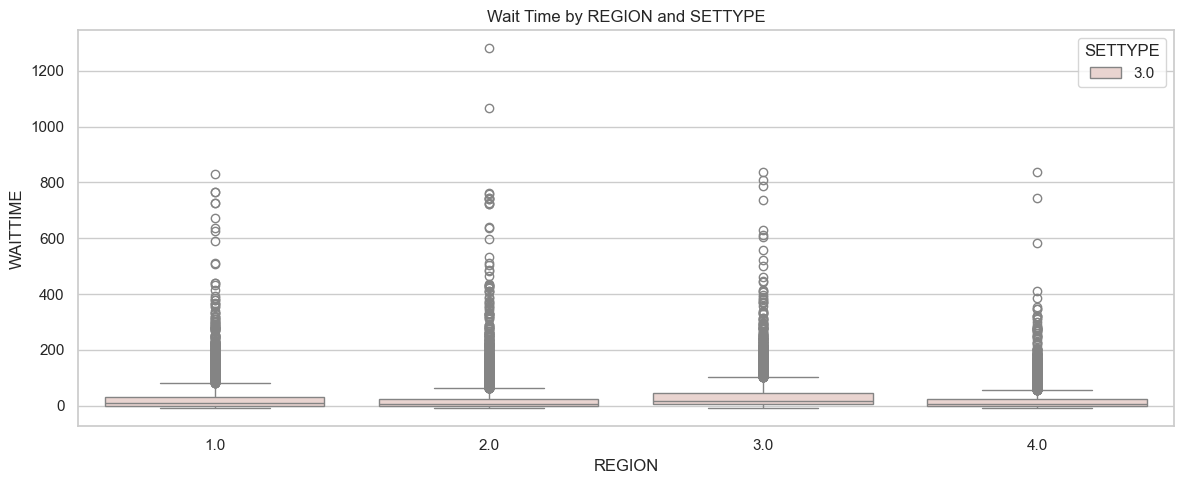

In [7]:
# Compare wait time by REGION and SETTYPE first.
region_settype_summary = (
    raw_analysis_df.groupby(['REGION', 'SETTYPE'], dropna=False)['WAITTIME']
    .agg(['count', 'mean', 'median'])
    .reset_index()
    .sort_values(['count', 'mean'], ascending=[False, False])
)
display(region_settype_summary)

plt.figure(figsize=(12, 5))
sns.boxplot(data=raw_analysis_df, x='REGION', y='WAITTIME', hue='SETTYPE')
plt.title('Wait Time by REGION and SETTYPE')
plt.tight_layout()
plt.show()

In [8]:
# Identify whether the strongest feature-to-wait-time relationships change inside each REGION and SETTYPE group.
candidate_features = [c for c in ['AGE', 'SEX', 'RACEUN', 'ETHUN', 'IMMEDR', 'PAINSCALE', 'LOV', 'ADMIT', 'FASTTRAK', 'OBSCLIN', 'BOARD', 'BPSYS', 'BPDIAS', 'TEMPF', 'PULSE', 'RESPR', 'POPCT', 'ARRIVAL_HOUR'] if c in raw_analysis_df.columns]
grouped_corr_rows = []
for (region, settype), group in raw_analysis_df.groupby(['REGION', 'SETTYPE'], dropna=False):
    if len(group) < 50:
        continue
    corr_data = group[['WAITTIME'] + candidate_features].apply(pd.to_numeric, errors='coerce')
    corr_values = corr_data.corr(numeric_only=True)['WAITTIME'].drop('WAITTIME').dropna()
    top = corr_values.reindex(corr_values.abs().sort_values(ascending=False).index).head(5)
    for feature, corr_value in top.items():
        grouped_corr_rows.append({
            'REGION': region,
            'SETTYPE': settype,
            'feature': feature,
            'pearson_corr': corr_value,
            'group_size': len(group),
        })

grouped_corr_df = pd.DataFrame(grouped_corr_rows)
display(grouped_corr_df.sort_values(['REGION', 'SETTYPE', 'pearson_corr'], ascending=[True, True, False]))

,REGION,SETTYPE,feature,pearson_corr,group_size
0,1.0,3.0,LOV,0.144482,3459
1,1.0,3.0,TEMPF,0.106984,3459
2,1.0,3.0,POPCT,0.105724,3459
4,1.0,3.0,BPDIAS,0.088250,3459
3,1.0,3.0,PULSE,-0.104669,3459
5,2.0,3.0,LOV,0.175233,4512
6,2.0,3.0,ADMIT,0.068491,4512
8,2.0,3.0,ETHUN,0.061697,4512
9,2.0,3.0,RACEUN,0.061599,4512
7,2.0,3.0,PAINSCALE,-0.064031,4512


In [9]:
# Show the strongest feature within each REGION x SETTYPE subgroup.
if not grouped_corr_df.empty:
    best_by_group = (
        grouped_corr_df.assign(abs_corr=grouped_corr_df['pearson_corr'].abs())
        .sort_values(['REGION', 'SETTYPE', 'abs_corr'], ascending=[True, True, False])
        .groupby(['REGION', 'SETTYPE'], as_index=False)
        .head(1)
        .drop(columns='abs_corr')
    )
    display(best_by_group)

    pivot = grouped_corr_df.pivot_table(index='feature', columns=['REGION', 'SETTYPE'], values='pearson_corr', aggfunc='mean')
    display(pivot)

,REGION,SETTYPE,feature,pearson_corr,group_size
0,1.0,3.0,LOV,0.144482,3459
5,2.0,3.0,LOV,0.175233,4512
10,3.0,3.0,LOV,0.158944,4124
15,4.0,3.0,LOV,0.132327,3930


REGION,1.0,2.0,3.0,4.0
SETTYPE,3.0,3.0,3.0,3.0
feature,,,,
ADMIT,NaN,0.068491,NaN,NaN
BPDIAS,0.088250,NaN,0.074001,NaN
ETHUN,NaN,0.061697,NaN,NaN
LOV,0.144482,0.175233,0.158944,0.132327
PAINSCALE,NaN,-0.064031,NaN,0.094196
POPCT,0.105724,NaN,NaN,0.083497
PULSE,-0.104669,NaN,0.138531,NaN
RACEUN,NaN,0.061599,NaN,NaN
